# Session 05

## Decision Trees


In [35]:
# import statements
import os
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.datasets import load_digits, load_iris, make_blobs,load_breast_cancer
from sklearn.tree import DecisionTreeClassifier, export_graphviz, DecisionTreeRegressor
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import accuracy_score, confusion_matrix, ConfusionMatrixDisplay

import graphviz


import matplotlib.image as mpimg




In [1]:
# inpDir = os.path.join('..','..','input')
# outDir = '../output'
# moduleDir = 'machine_learning'



## Basic Parameter


RANDOM_STATE = 24
np.random.seed(RANDOM_STATE)

TEST_SIZE = 0.2


NameError: name 'np' is not defined

pip install graphviz

In [37]:
decision_tree = graphviz.Digraph(node_attr={'shape':'box'},
                                 edge_attr={'labeldistance':'10.5'},
                                 format = 'png')
decision_tree.node("0",'Has Feathers?')
decision_tree.node("1",'Can Fly?')
decision_tree.node("2",'Fins?')
decision_tree.node("3",'Hawk?')
decision_tree.node("4",'Penguin?')
decision_tree.node("5",'Dolphin?')
decision_tree.node("6",'Bear?')

decision_tree.edge("0","1", label = "True")
decision_tree.edge("0","2", label = "False")

decision_tree.edge("1","3", label = "True")
decision_tree.edge("1","4", label = "False")

decision_tree.edge("2","5", label = "True")
decision_tree.edge("2","6", label = "False")

decision_tree.render('decision_tree')



'decision_tree.png'

his line is the core of the code. It uses the train_test_split function to split the loaded dataset (data) into training and testing sets:
data.data: This represents the features or independent variables in your dataset. It's assumed to be a 2D array-like structure (e.g., NumPy array, pandas DataFrame) where each row represents a data point and each column represents a feature.
data.target: This represents the target variable or labels in your dataset. It's assumed to be a 1D array-like structure (e.g., NumPy array, pandas Series) containing the class labels (e.g., 0 or 1 for binary classification) for each data point.
Parameters:

random_state: (Optional) This parameter sets the random seed for shuffling the data before splitting. Using a fixed seed ensures reproducibility of the split across multiple runs of your code.
test_size: (Optional) This parameter controls the proportion of data to be allocated to the test set. It can be a float (between 0.0 and 1.0, representing the proportion) or an integer (representing the absolute number of test samples). If not specified, it defaults to 0.25 (25%).
stratify=data.target: (Optional but important for classification) This parameter ensures that the class labels (categories) are proportionally represented in both the training and testing sets. This is crucial to avoid biased model evaluation, especially for imbalanced datasets.
Output:

The function returns four variables:
X_train: The training set for features (2D array-like structure).
X_test: The testing set for features (2D array-like structure).
y_train: The training set for target variables (1D array-like structure).
y_test: The testing set for target variables (1D array-like structure).
Shapes:

Python
X_train.shape, X_test.shape, y_train.shape, y_test.shape
Use code with caution.
content_copy
This line (conceptually, not necessarily executed in practice) prints the shapes of the resulting arrays. The shapes will typically be:
X_train.shape: (n_train_samples, n_features), where n_train_samples is the number of data points in the training set and n_features is the number of features (columns) in your dataset.
X_test.shape: (n_test_samples, n_features), where n_test_samples is the number of data points in the testing set.
y_train.shape: (n_train_samples,), representing a 1D array with the number of elements equal to n_train_samples.
y_test.shape: (n_test_samples,), representing a 1D array with the number of elements equal to n_test_samples.
In essence:

You load a dataset (assuming you have a function to do that).
You split the data into training and testing sets using train_test_split, ensuring stratified splitting for classification tasks.
The resulting training set (features and target variables) will be used to train your machine learning model.
The testing set (features and target variables) will be used to evaluate the performance of your trained model on unseen data.

In [38]:
from sklearn.model_selection import train_test_split

data =load_breast_cancer()  #Assuming you have a function to load the breast cancer dataset
X_train, X_test,y_train,y_test=train_test_split(data.data,data.target, 
                                                random_state=RANDOM_STATE,
                                                test_size=TEST_SIZE,
                                                stratify=data.target)

X_train.shape, X_test.shape,y_train.shape,y_test.shape


((455, 30), (114, 30), (455,), (114,))

In [39]:
tree = DecisionTreeClassifier(random_state=RANDOM_STATE)

tree.fit(X_train,y_train)

y_pred = tree.predict(X_test)

accuracy_score(y_test,y_pred)

0.8947368421052632

In [40]:
y_pred = tree.predict(X_train)
accuracy_score(y_train, y_pred)

1.0

In [41]:
tree = DecisionTreeClassifier(max_depth=3, random_state=RANDOM_STATE)

tree.fit(X_train,y_train)

y_pred = tree.predict(X_train)

print('Train',accuracy_score(y_train,y_pred))

y_pred = tree.predict(X_test)

print('Test',accuracy_score(y_test, y_pred))




Train 0.9824175824175824
Test 0.8859649122807017


In [42]:
data.keys()

dict_keys(['data', 'target', 'frame', 'target_names', 'DESCR', 'feature_names', 'filename', 'data_module'])

In [43]:
export_graphviz(tree,out_file='tree.dot',
                impurity=False,
                filled=True,
                class_names=data.target_names)

TypeError: Image data of dtype <U8 cannot be converted to float

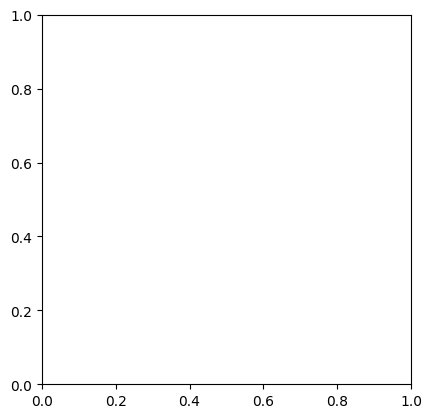

In [44]:
import graphviz

with open('tree.dot') as f:
    dot_graph = f.read()
img = graphviz.Source(dot_graph)
!dot -Tpng tree.dot -o tree.png
plt.imshow('tree.png')

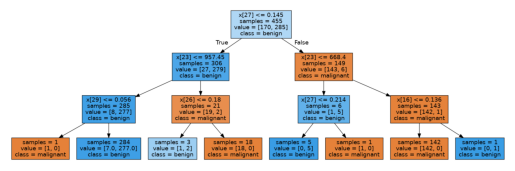

In [ ]:
plt.imshow(mpimg.imread('tree.png'))
plt.axis('off');

In [45]:
make_blobs

<function sklearn.datasets._samples_generator.make_blobs(n_samples=100, n_features=2, *, centers=None, cluster_std=1.0, center_box=(-10.0, 10.0), shuffle=True, random_state=None, return_centers=False)>

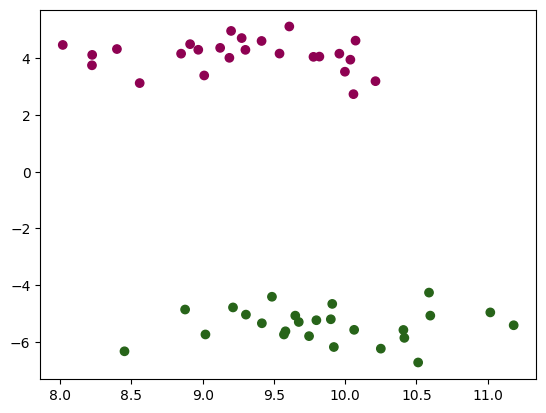

In [ ]:
X, y = make_blobs(n_samples=50, centers=2, random_state=RANDOM_STATE, cluster_std=0.60)

plt.scatter(X[:,0], X[:,1], c = y, cmap = plt.cm.PiYG)

In [ ]:
clf = SVC(kernel='linear')
clf.fit(X,y)
y_pred = clf.predict(X)
accuracy_score(y, y_pred)

NameError: name 'SVC' is not defined

In [ ]:
confusion_matrix(y, y_pred)

array([[25,  0],
       [ 0, 25]])

In [ ]:
X

array([[ 9.27334708,  4.71480252],
       [ 8.84842323,  4.16467305],
       [10.07240087,  4.62488346],
       [ 9.01922667, -5.7396746 ],
       [11.01792948, -4.96185615],
       [ 8.96893596,  4.3021318 ],
       [ 9.19912194,  4.96691845],
       [ 8.39818466,  4.32795768],
       [10.05773629,  2.73662843],
       [ 9.95880809,  4.16426187],
       [ 9.77726911,  4.05264772],
       [ 9.5701748 , -5.74085459],
       [ 9.30329474, -5.03987144],
       [ 8.87655768, -4.86020755],
       [ 9.99787337,  3.52822093],
       [10.414828  , -5.86024715],
       [ 9.41304174,  4.61275758],
       [ 9.67396781, -5.29914727],
       [ 9.6495809 , -5.07599034],
       [ 9.81867627,  4.06109976],
       [10.59690301, -5.07525235],
       [ 8.22309435,  3.75482464],
       [11.18189255, -5.41480178],
       [ 8.22450353,  4.12198012],
       [ 9.60762895,  5.12380464],
       [ 9.21261058, -4.78638298],
       [ 9.92023226, -6.18262152],
       [10.40817185, -5.58097659],
       [10.2122958 ,

In [ ]:
X.shape

(50, 2)

In [ ]:
y

array([0, 0, 0, 1, 1, 0, 0, 0, 0, 0, 0, 1, 1, 1, 0, 1, 0, 1, 1, 0, 1, 0,
       1, 0, 0, 1, 1, 1, 0, 1, 0, 0, 1, 1, 0, 1, 1, 0, 1, 0, 1, 1, 0, 0,
       0, 0, 1, 1, 1, 1])

(0.0, 1.0)

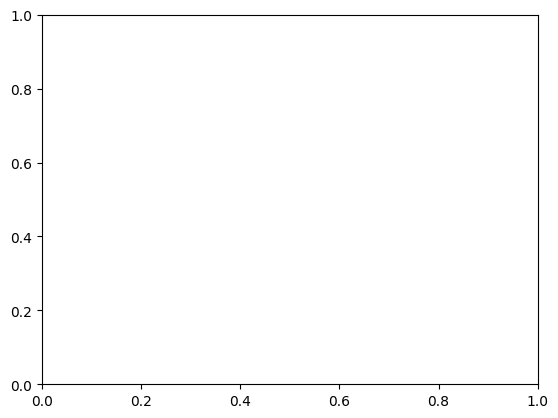

In [ ]:
plt.xlim() #X limit

(0.0, 1.0)

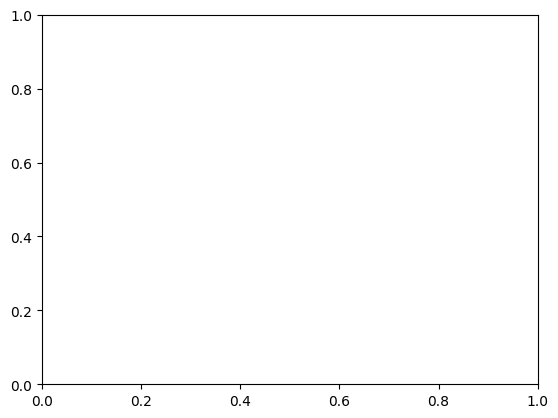

In [ ]:
plt.ylim()  #y limit

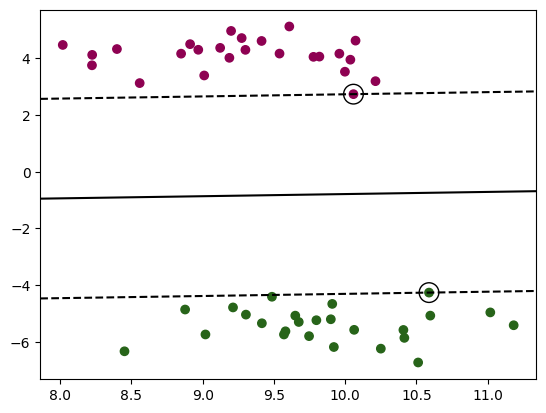

In [ ]:
plt.scatter(X[:,0], X[:,1], c = y, cmap = plt.cm.PiYG)
xLim=np.linspace(plt.xlim()[0], plt.xlim()[1], 30)
yLim=np.linspace(plt.ylim()[0], plt.ylim()[1], 30)

YY,XX = np.meshgrid(yLim,xLim) #generate a mesh
preds = np .zeros_like(XX)

for i ,xi in enumerate(xLim):
    for j , yj in enumerate(yLim):
        preds[i,j]=clf.decision_function(np.array([xi,yj]).reshape(1,-1)).item()
        

plt.contour(XX,YY,preds,colors='k', levels=[-1, 0, 1], linestyles = [ '--', '-', '--' ])


plt.scatter(clf.support_vectors_[:,0], clf.support_vectors_[:,1], s = 200, edgecolors='k', facecolor = 'none')


In [ ]:
clf.support_vectors_

array([[10.05773629,  2.73662843],
       [10.58790014, -4.26295838]])

In [ ]:
digits = load_digits()
print(digits.keys())

dict_keys(['data', 'target', 'frame', 'feature_names', 'target_names', 'images', 'DESCR'])


In [ ]:
print(digits.DESCR)

.. _digits_dataset:

Optical recognition of handwritten digits dataset
--------------------------------------------------

**Data Set Characteristics:**

:Number of Instances: 1797
:Number of Attributes: 64
:Attribute Information: 8x8 image of integer pixels in the range 0..16.
:Missing Attribute Values: None
:Creator: E. Alpaydin (alpaydin '@' boun.edu.tr)
:Date: July; 1998

This is a copy of the test set of the UCI ML hand-written digits datasets
https://archive.ics.uci.edu/ml/datasets/Optical+Recognition+of+Handwritten+Digits

The data set contains images of hand-written digits: 10 classes where
each class refers to a digit.

Preprocessing programs made available by NIST were used to extract
normalized bitmaps of handwritten digits from a preprinted form. From a
total of 43 people, 30 contributed to the training set and different 13
to the test set. 32x32 bitmaps are divided into nonoverlapping blocks of
4x4 and the number of on pixels are counted in each block. This generates
an in

In [ ]:
X_train, X_test, y_train, y_test = train_test_split(digits.data, 
digits.target, stratify = digits.target, test_size=TEST_SIZE, random_state=RANDOM_STATE)

X_train.shape, X_test.shape,y_train.shape,y_test.shape

((1437, 64), (360, 64), (1437,), (360,))

SVC: kernel :linear  | F1 score : 0.9777
SVC: kernel :rbf     | F1 score : 0.9861
SVC: kernel :poly    | F1 score : 0.9916


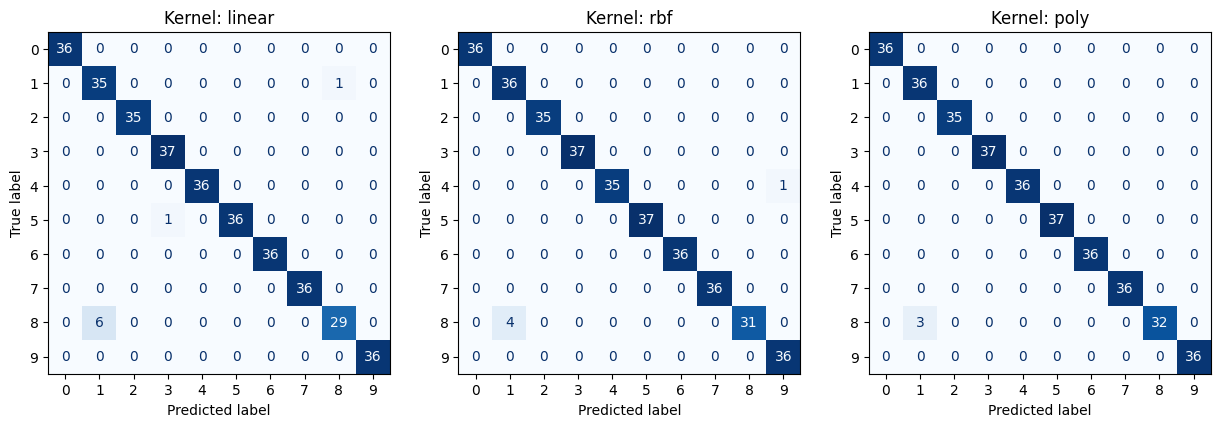

In [ ]:
from sklearn.metrics import f1_score, confusion_matrix,ConfusionMatrixDisplay

fig, axes = plt.subplots(1,3, figsize = (15,8)) # instantiate plt object

for i , knl in enumerate(['linear','rbf','poly']):
    clf=SVC(kernel=knl).fit(X_train,y_train)
    y_pred=clf.predict(X_test)
    print (f'SVC: kernel :{knl:<7} | F1 score : {f1_score(y_test,y_pred,average="weighted"):.4f}')
    
    cm = confusion_matrix(y_test, y_pred)
    
    disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=digits.target_names)
    
    disp.plot(ax = axes[i], cmap=plt.cm.Blues, colorbar = False)
    axes[i].set_title(f'Kernel: {knl}')

In [ ]:
from sklearn.metrics import f1_score, confusion_matrix,ConfusionMatrixDisplay
f1_score(y_test,y_pred,average="weighted")

0.9916467661691541

In [ ]:
digits.data.shape

(1797, 64)

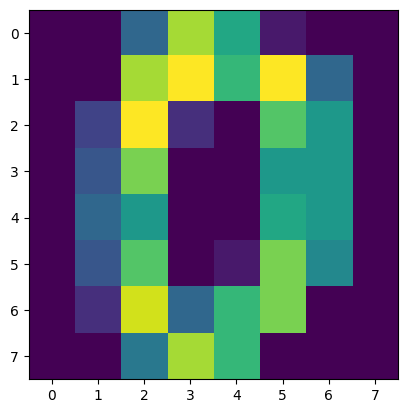

In [ ]:
plt.imshow(digits.data[0].reshape(8,8))

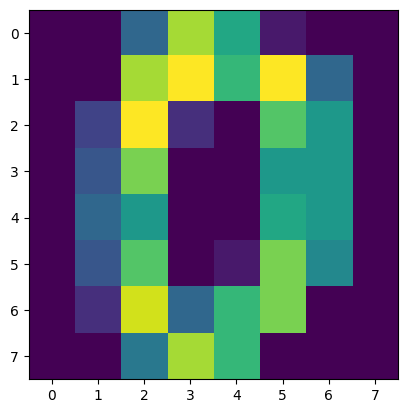

In [ ]:
plt.imshow(digits.data[0].reshape(8,8))

In [ ]:
iris=load_iris()

features=iris.data
labels=iris.target

features.shape, labels.shape

((150, 4), (150,))

In [ ]:
#for convenience create a funtion to plot

def plot_hyplane(classfier,features,labels,i):
    plt.subplot(1, 3, i)
    plt.subplots_adjust(wspace=0.2,hspace=0.2)
    pred=classfier.predict(features) #make prediction
    
    x_min,x_max=features[:,0].min()- .1,features[:,0].max()+.1
    y_min,y_max=features[:,1].min()- .1,features[:,1].max()+.1

    xx,yy =np.meshgrid(np.linspace(x_min,x_max,1000),np.linspace(y_min,y_max,1000))
    
    Z=classfier.predict(np.c_[xx.ravel(),yy.ravel()])
    
    #plot the decision surfacve
    Z = Z.reshape(xx.shape)
   
    plt.grid(False)
    plt.pcolormesh(xx, yy, Z, cmap = plt.cm.Set3) # refer http://matplotlib.org/users/colormaps.html
    
    # Plot also the training points
    plt.scatter( features [ :,0], features [:,1], c = labels, cmap=plt.cm.flag,s=10)
    
    plt.axis('tight')


In [ ]:
from sklearn.decomposition import PCA

pca = PCA(n_components = 2)
pca_features = pca.fit_transform(features)
features.shape, pca_features.shape

((150, 4), (150, 2))

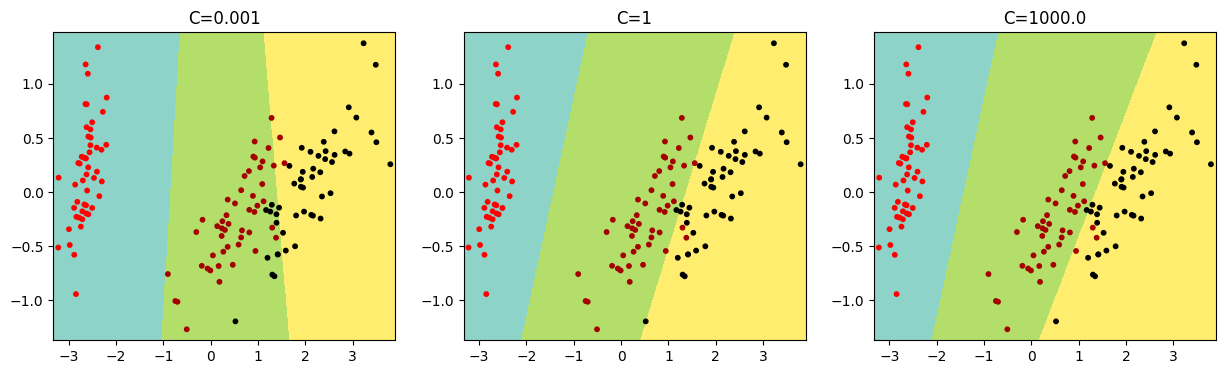

In [ ]:
fig, axes = plt.subplots(1,3,figsize=(15,4))

C_values =  [1e-3,1,1e3]

for i , C in enumerate(C_values):
    clf = SVC(kernel='linear', C=C)
    
    clf.fit(pca_features,labels)
    
    plot_hyplane(clf,pca_features,labels,i+1)
    
    plt.title(f'C={C}')
    
plt.show()

# # Gamma
- Small gamma $\rightarrow$ low bias , high variance
- Large Gamma $\rightarrow$ high bias , low variance

gamma = [0.001,1,'auto']

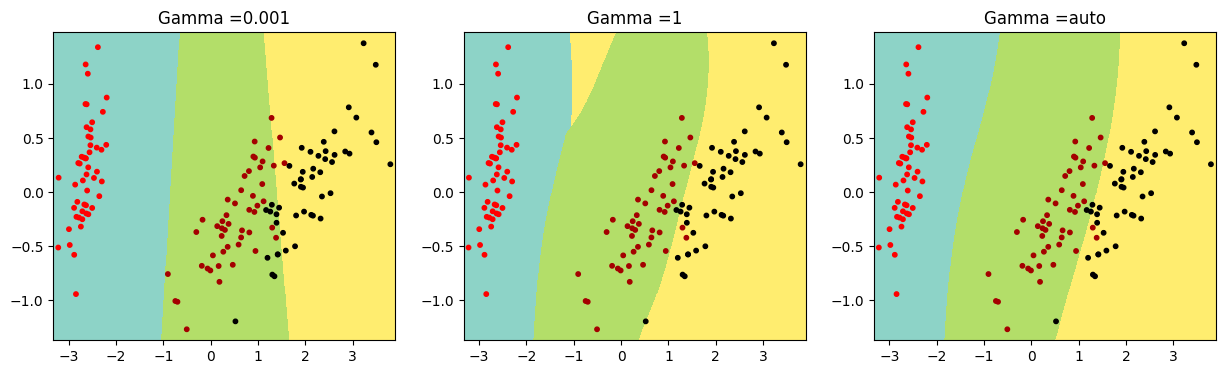

In [ ]:
fig, axes = plt.subplots(1,3,figsize=(15,4))

gammas    =  [0.001,1,'auto']

for i,gm in enumerate(gammas):
    clf = SVC(kernel='rbf', gamma=gm)
    
    clf.fit(pca_features,labels)
    
    plot_hyplane(clf,pca_features,labels,i+1)
    
    plt.title(f'Gamma ={gm}')
    
plt.show()